In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10
%pip install matplotlib

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
from IPython.display import display

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.

# BB84 protocol with two agents


# General steps:
1. Generate random sequence of bits by first user (can be provided by user)
1. Each bit represented by a qubit using either two schemes, standard or diagonal
1. Randomly go through each bit, transform each bit into standard or diagonal
1. Sends bits to second "user", can be instant accessed through a variable
1. For each qubit received: do measurement with random scheme
1. return user 2's chosen operations to user 1
1. user 1 checks both their own operations and user 2's operations
1. user 1 replies with the positions of the decoded bit array that match user 2's operations

# Helper Functions
We've created two helper functions to simplify some of the logic required to simulate the BB84 protocol:
1. `measure_circuit(circuit)`
This function takes in a `QuantumCircuit` and measures every qubit, this is ran with an `AERSimulator` once and the result is returned in little-endian ordering done by `result[::-1]`
2. `generate_bits(n)`
This function takes in `n` as the number of qubits to create for a `QuantumCircuit`, all randomly generated through a `H`-gate

In [3]:
# let user 1 generate a random sequence of bits, configurable by n
# the bits will be generated through a quantum circuit with n qubits, done with hadamard gate then measured
num_bits = 16

def measure_circuit(circuit):
    circuit_to_measure = circuit.copy()
    circuit_to_measure.measure_all()
    simulator = AerSimulator()
    compiled_circuit = transpile(circuit_to_measure, simulator)
    job = simulator.run(compiled_circuit, shots=1) # only run once, since we only need to generate the bit sequence once
    result = job.result()
    counts = result.get_counts(circuit)
    result = list(counts.keys())[0]
    return result[::-1] # reversing bit-string, since result is little-endian

def generate_bits(n):
    circuit = QuantumCircuit(n) # creating circuit with n bits
    circuit.h(range(n)) # applying hadamard gate to all qubits

    # retrieve bits through simulator
    return measure_circuit(circuit)




# Alice's Bits (User 1)
User 1 generates a random sequence of qubits as their original bits with a pre-configured `num_bits` set on top. This simulator supports up to 30!
User 1 also decides their sequence of basis with the same `generate_bits` function, with `0` being the standard `|0>` and `|1>` qubits and `1` being the diagonal `|+>` and `|->` qubits

In [ ]:
# creating user 1's original bits and bases
original_bits = generate_bits(num_bits)
user_1_bases = generate_bits(num_bits) # random bits for user 1 base, 0 being standard, 1 being diagonal

print(f"original bits from user 1: {original_bits}")
print(f"user 1 base: {user_1_bases}")

original bits from user 1: 0000111001111010
user 1 base: 0110000100101001


# Creating the Quantum Circuit
With the initial classical bits and bases User 1 has selected before, User 1 packages the qubits into a `QuantumCircuit` using the `encode_bits(bits, bases)` function below.
The function simply checks each bit to see if:
1. the bit is equal to 1:
The `X`-gate is applied to flip the bit from `|0>` to `|1>`
2. the basis for that bit is diagonal (1):
The `H`-gate is applied to switch the qubit to either `|->` or `|+>`

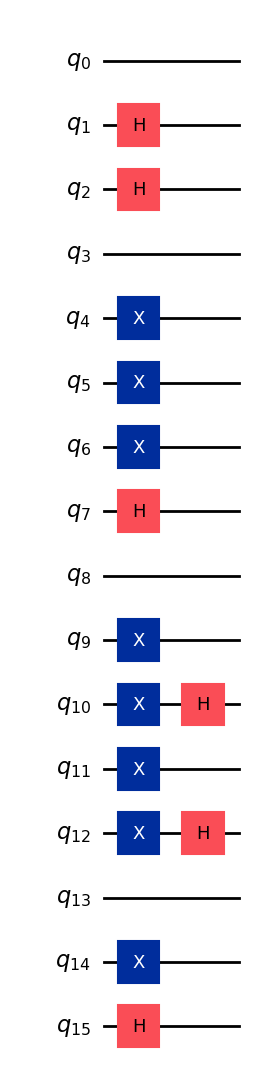

User 1's Encoded Bits Quantized:


<IPython.core.display.Latex object>

In [5]:
# convert each bit in original bits to their respective scheme
def encode_bits(bits, bases):
    circuit = QuantumCircuit(len(bits))
    for index, bit in enumerate(bits):
        if bit == '1': # regardless of the scheme, the qubit has to be flipped to 1 with X-gate
            # apply x-gate
            circuit.x(index)
        if bases[index] == '1': # if the basis is 1, user has chosen "diagonal", apply H-gate to switch to |-> or |+>
            # apply h-gate
            circuit.h(index)
    return circuit

# simulated: this entire encoded_bits is handed off to user 2, no longer accessible by user 1
encoded_bits = encode_bits(original_bits,user_1_bases)
display(encoded_bits.draw("mpl"))
quantized_encoded_bits = Statevector(encoded_bits)
print("User 1's Encoded Bits Quantized:")
display(quantized_encoded_bits.draw('latex'))



# User 2 Receives Qubits
In this next step, we simulate User 2 "receiving" the qubits from User 1 and they perform a series of tasks
1. User 2 randomly decides their list of basis to apply using our `generate_bits` function
2. User 2 takes the qubits received from User 1 and measures the qubits with their list of basis
3. User 2 "returns" their selected bases to User 1 on their public channel (simulated)

User 2's bases: 1010101010110111
Compared to user 1's bases: 0110000100101001


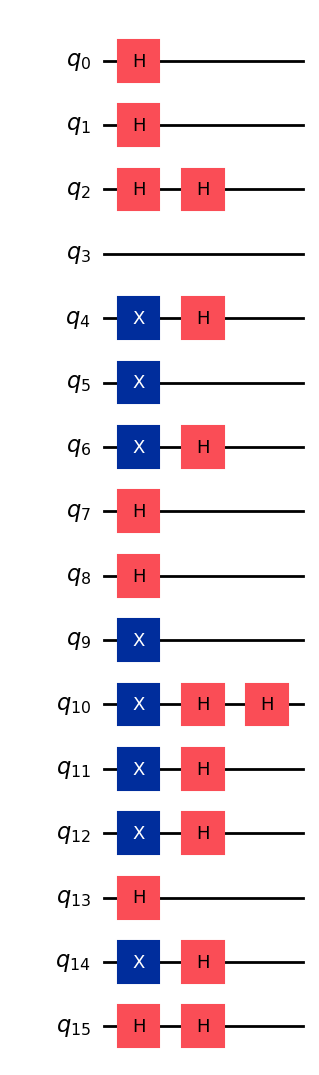

User 2's Encoded Bits Quantized:


<IPython.core.display.Latex object>

User 2's bits: 0000111101101000
Compared to user 1's bits: 0000111001111010


In [6]:
# user 2 retrieves the encoded bits, user 2 also generates his own bases
user_2_bases = generate_bits(num_bits)
print(f"User 2's bases: {user_2_bases}")
print(f"Compared to user 1's bases: {user_1_bases}")
# user 2 now loops through each qubit and apply chosen basis (only diagonal, since the bits are already qubits, so |0> and |1> can be ignored if standard)
for index, scheme in enumerate(user_2_bases):
    if scheme == '1': # recall that scheme = 1 represents diagonal scheme
        encoded_bits.h(index)

# peek into how user 2's quantized states look like:
display(encoded_bits.draw("mpl"))
quantized_user_2_bits = Statevector(encoded_bits)
print("User 2's Encoded Bits Quantized:")
display(quantized_user_2_bits.draw('latex'))

# time to measure user 2s bits!
user_2_bits = measure_circuit(encoded_bits)
print(f"User 2's bits: {user_2_bits}")
print(f"Compared to user 1's bits: {original_bits}")


# Retrieving the final key
User 1 takes User 2's list of basis and compares with their own. If the basis selected for a specific index matches their own, they add it to their list of `matching_indexes` and returns it to User 2 on the public channel.

User 2 receives this list of `matching_indexes` and both users will use this list to obtain the classical bits for their key by taking the bits from the indexes specified in `matching_indexes` in `original_bits`

They then both compare physically whether their keys matched, in this scenario without an attacker, the keys should match 1-1!

In [ ]:
# simulated passing user_2_bases to user_1, user 1 will check user 2s base and compare with their own here
matching_indexes = []
user_1_matching_bits = ""
for index, base in enumerate(user_2_bases):
    if base == user_1_bases[index]:
        # save the bit and index in an array
        matching_indexes.append(index)
        user_1_matching_bits += original_bits[index]

print(f"Matching indexes found by user 1: {matching_indexes}")
print("Sending matching indexes to user 2")
# user 1 will advertise matching_indexes to user 2

# user 2 receives matching indexes and does the same to retrieve matching_bits
print("User 2 retrieved matching indexes")
user_2_matching_bits = ""
for index in matching_indexes:
    user_2_matching_bits += user_2_bits[index]

print(f"User 1's matching bits: {user_1_matching_bits}")
print(f"User 2's matching bits: {user_2_matching_bits}")

if user_1_matching_bits == user_2_matching_bits:
    print("Both bits (keys) match!")
else:
    print("Keys not matching, error in algorithm!")


Matching indexes found by user 1: [2, 3, 5, 9, 10, 15]
Sending matching indexes to user 2
User 2 retrieved matching indexes
User 1's matching bits: 001110
User 2's matching bits: 001110
Both bits (keys) match!


: 